# Step 4 Three crack tips with an angle
Simple extension of step 3 by introducing angle in one arm.
This doesn't use the Recho Hamiltonian to calculate the release energy as we are looking at isotropic ice in this notebook.

In [ ]:
# Step 4: Angled V-notch (3 tips) with SIF-based, angle-dependent edge weights
# (repeat Step 3 mostly)

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


In [2]:
# ---- Material: isotropic ice, plane strain ----
E_ice = 9.0e9      # Pa
nu_ice = 0.33
E_eff_plane_strain = E_ice / (1.0 - nu_ice**2)

# ---- Far-field loads (global Cartesian) ----
# We'll treat far-field stress tensor as:
#   [sigma_xx, tau_xy]
#   [tau_xy,   sigma_yy]
# For the Step 3 analogue, set sigma_yy = sigma_inf, sigma_xx = 0, tau_xy = tau_inf.
sigma_inf = 1e5
tau_inf   = 0.0


In [40]:
def build_v_notch_tip_positions(alpha: float, L: float = 1.0, ratio: float = 2.0):
    """
    3-tip V-notch:
      node 1: apex at (0,0)
      node 0: arm at (-L, 0)
      node 2: arm at (ratio*L*cos(alpha), ratio*L*sin(alpha))
    """
    apex = (0.0, 0.0)
    tip0 = (-L,  0.0)
    tip2 = (ratio * L * np.cos(alpha), ratio * L * np.sin(alpha))
    return {0: tip0, 1: apex, 2: tip2}

def infer_node_theta_for_v_notch(node_id: int, alpha: float) -> float:
    if node_id == 0:
        return np.pi
    if node_id == 2:
        return alpha
    return 0.0

alphas = [np.pi/6, np.pi/4, np.pi/3]
L = 1.0
ratio = 1.0

tip_positions = build_v_notch_tip_positions(alpha=alphas[0], L=L, ratio=ratio)
tip_positions



{0: (-1.0, 0.0),
 1: (0.0, 0.0),
 2: (np.float64(0.8660254037844387), np.float64(0.49999999999999994))}

In [41]:
def build_v_notch_segments(L: float = 1.0, ratio: float = 1.0):
    return [
        (1, 0, 0.5 * L),
        (1, 2, 0.5 * ratio * L),
    ]

def segment_angle(G: nx.Graph, i: int, j: int) -> float:
    xi, yi = G.nodes[i]["x"], G.nodes[i]["y"]
    xj, yj = G.nodes[j]["x"], G.nodes[j]["y"]
    return float(np.arctan2(yj - yi, xj - xi))

segments = build_v_notch_segments(L=L, ratio=ratio)
segments

[(1, 0, 0.5), (1, 2, 0.5)]

In [42]:
def isotropic_plane_strain_stiffness(E: float, nu: float) -> np.ndarray:
    lam = E * nu / ((1 + nu) * (1 - 2 * nu))
    mu = E / (2 * (1 + nu))
    C = np.array([
        [lam + 2 * mu, lam,           0.0],
        [lam,           lam + 2 * mu, 0.0],
        [0.0,           0.0,          mu ],
    ])
    return C

C_iso_ice_3x3 = isotropic_plane_strain_stiffness(E_ice, nu_ice)

def crack_tip_hamiltonian_data(C: np.ndarray, theta: float = 0.0) -> dict:
    # Extract a symmetric 2x2 block (yy / xy components)
    C22 = C[1, 1]
    C24 = C[1, 2]
    C42 = C[2, 1]
    C44 = C[2, 2]

    # Orientation factor (toy): f(theta) ~ 1 + 0.1 cos(2θ)
    f_theta = 1.0 + 0.1 * np.cos(2.0 * theta)

    H = f_theta * np.array([
        [C22, C24],
        [C42, C44],
    ], dtype=float)

    H_eigvals = np.linalg.eigvals(H)
    lambda_sing = 0.5  # placeholder

    return {"H": H, "H_eigvals": H_eigvals, "lambda_sing": lambda_sing}


In [43]:
def infer_node_theta_for_v_notch(node_id: int, alpha: float) -> float:
    if node_id == 0:
        return +alpha
    if node_id == 2:
        return -alpha
    return 0.0  # apex

def build_three_tip_graph_with_H(C: np.ndarray, tip_positions: dict, alpha: float) -> nx.Graph:
    G = nx.Graph()
    for j, (x, y) in tip_positions.items():
        theta = infer_node_theta_for_v_notch(j, alpha)
        tip_data = crack_tip_hamiltonian_data(C=C, theta=theta)
        G.add_node(j, id=j, x=x, y=y, theta=theta, **tip_data)
    return G


In [35]:
def global_stress_tensor(sigma_xx: float, sigma_yy: float, tau_xy: float) -> np.ndarray:
    return np.array([[sigma_xx, tau_xy],
                     [tau_xy,   sigma_yy]], dtype=float)

def resolve_tractions_on_plane(stress: np.ndarray, phi: float) -> tuple[float, float]:
    """
    Resolve (sigma_n, tau_nt) on a plane whose tangent is at angle phi from +x.
    """
    t = np.array([np.cos(phi), np.sin(phi)], dtype=float)           # tangent
    n = np.array([-np.sin(phi), np.cos(phi)], dtype=float)          # normal (90° CCW)

    sigma_n = float(n @ stress @ n)
    tau_nt  = float(t @ stress @ n)
    return sigma_n, tau_nt

def sif_from_resolved_tractions(a: float, sigma_n: float, tau_nt: float) -> tuple[float, float]:
    factor = np.sqrt(np.pi * a)
    K_I  = sigma_n * factor
    K_II = tau_nt  * factor
    return K_I, K_II

def energy_release_plane_strain(K_I: float, K_II: float, E_eff: float) -> float:
    return (K_I**2 + K_II**2) / E_eff


In [36]:
def segment_angle(G: nx.Graph, i: int, j: int) -> float:
    xi, yi = G.nodes[i]["x"], G.nodes[i]["y"]
    xj, yj = G.nodes[j]["x"], G.nodes[j]["y"]
    return float(np.arctan2(yj - yi, xj - xi))

def add_angle_dependent_sif_edges_to_graph(G: nx.Graph,
                                          segments: list[tuple[int, int, float]],
                                          sigma_inf: float,
                                          tau_inf: float,
                                          E_eff: float,
                                          sigma_xx: float = 0.0) -> None:
    """
    Like Step 3 'add_sif_edges_to_graph', but:
      - compute segment orientation phi from node coordinates,
      - resolve global stress onto crack plane to get sigma_n and tau_nt,
      - use these as Mode I/II driving tractions.
    """
    stress = global_stress_tensor(sigma_xx=sigma_xx, sigma_yy=sigma_inf, tau_xy=tau_inf)

    for i, j, a in segments:
        phi = segment_angle(G, i, j)
        sigma_n, tau_nt = resolve_tractions_on_plane(stress, phi)
        K_I, K_II = sif_from_resolved_tractions(a, sigma_n, tau_nt)
        G_edge = energy_release_plane_strain(K_I, K_II, E_eff)

        G.add_edge(
            i, j,
            a=a,
            phi=phi,
            sigma_n=sigma_n,
            tau_nt=tau_nt,
            K_I=K_I,
            K_II=K_II,
            G_edge=G_edge,
            weight=G_edge
        )


In [37]:
def get_weighted_adjacency(G: nx.Graph) -> tuple[np.ndarray, list[int]]:
    nodes = sorted(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodes, weight="weight", dtype=float)
    return A, nodes

def plot_three_tip_graph(G: nx.Graph, title: str | None = None) -> None:
    pos = {n: (d["x"], d["y"]) for n, d in G.nodes(data=True)}

    plt.figure(figsize=(5, 4))
    nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=500)
    nx.draw_networkx_labels(G, pos, font_size=12)
    nx.draw_networkx_edges(G, pos, width=2)

    edge_labels = {(u, v): f"{d['G_edge']:.2e}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=9, font_color="red")

    if title is None:
        title = "3-tip V-notch (angle-dependent SIF-based G_edge weights)"
    plt.title(title)
    plt.axis("equal")
    plt.axis("off")
    plt.tight_layout()
    plt.show()



alpha = 0.524 rad
  Edge (0-1): a=0.5, phi=3.142, sigma_n=1e+05, tau_nt=-1.22e-11, G=1.555e+00
  Edge (1-2): a=0.5, phi=0.524, sigma_n=7.5e+04, tau_nt=4.33e+04, G=1.166e+00


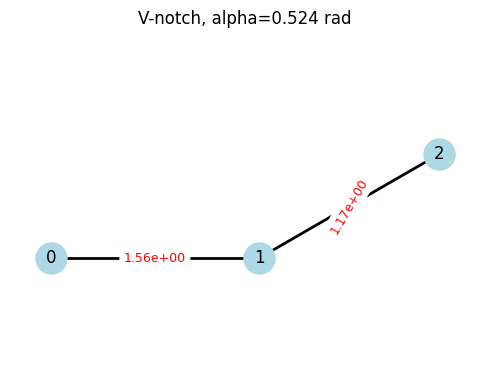

Adjacency (weights=G_edge), node order: [0, 1, 2]
[[0.         1.5552629  0.        ]
 [1.5552629  0.         1.16644717]
 [0.         1.16644717 0.        ]]

alpha = 0.785 rad
  Edge (0-1): a=0.5, phi=3.142, sigma_n=1e+05, tau_nt=-1.22e-11, G=1.555e+00
  Edge (1-2): a=0.5, phi=0.785, sigma_n=5e+04, tau_nt=5e+04, G=7.776e-01


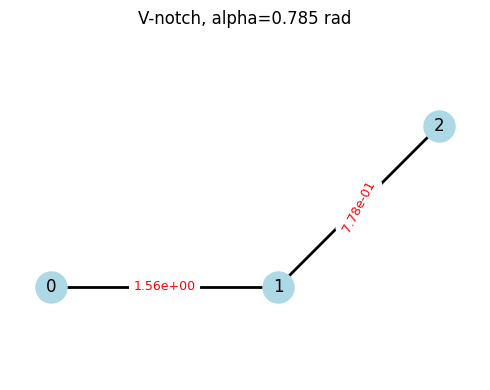

Adjacency (weights=G_edge), node order: [0, 1, 2]
[[0.         1.5552629  0.        ]
 [1.5552629  0.         0.77763145]
 [0.         0.77763145 0.        ]]

alpha = 1.047 rad
  Edge (0-1): a=0.5, phi=3.142, sigma_n=1e+05, tau_nt=-1.22e-11, G=1.555e+00
  Edge (1-2): a=0.5, phi=1.047, sigma_n=2.5e+04, tau_nt=4.33e+04, G=3.888e-01


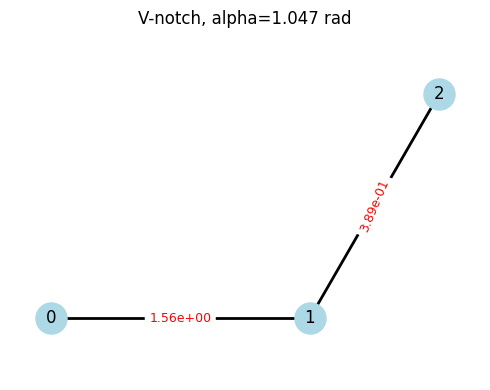

Adjacency (weights=G_edge), node order: [0, 1, 2]
[[0.         1.5552629  0.        ]
 [1.5552629  0.         0.38881572]
 [0.         0.38881572 0.        ]]


In [38]:
results = {}

for alpha in alphas:
    tip_positions = build_v_notch_tip_positions(alpha=alpha, L=L, ratio=ratio)
    segments = build_v_notch_segments(L=L, ratio=ratio)

    G_v = build_three_tip_graph_with_H(C_iso_ice_3x3, tip_positions, alpha=alpha)
    add_angle_dependent_sif_edges_to_graph(G_v, segments, sigma_inf, tau_inf, E_eff_plane_strain)

    A, node_order = get_weighted_adjacency(G_v)
    results[alpha] = (G_v, A, node_order)

    print(f"\nalpha = {alpha:.3f} rad")
    for u, v, d in G_v.edges(data=True):
        print(f"  Edge ({u}-{v}): a={d['a']:.3g}, phi={d['phi']:.3f}, "
              f"sigma_n={d['sigma_n']:.3g}, tau_nt={d['tau_nt']:.3g}, G={d['G_edge']:.3e}")

    plot_three_tip_graph(G_v, title=f"V-notch, alpha={alpha:.3f} rad")
    print("Adjacency (weights=G_edge), node order:", node_order)
    print(A)
